# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MohinaRustamova/lyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

I score the full portfolio with the honest grouped-split Logistic Regression from
w05/w06, then cross it with the Week-4 rule's reason codes (STALE_AND_UNDERPERFORMING,
CTR_BELOW_POSITION_PEERS, STALE_ONLY, NO_FLAG). The reason codes double as archetypes:
each one implies a different action. Rows from the 29 training clients are scored
in-sample (the model has seen that client before), rows from the 13 test clients are
out-of-sample (the validated Precision@20/@50 numbers apply to these). Both are
included in the queue, but the split is a labeled column, not hidden, since it changes
how much a reviewer should trust the score.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---- Setup: rebuild feature vector + honest model (same as w05/w06) ----
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL, REPO_DIR = "https://github.com/MohinaRustamova/flyrank-ml-internship", "flyrank-ml-internship"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

%pip -q install duckdb

import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

con = duckdb.connect()

if IN_COLAB:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
else:
    from getpass import getpass
    HF_TOKEN = getpass("HF_TOKEN: ")

con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

FACT = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')"
DIMC = "read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet')"
DECISION_DATE = "2026-03-31"

feature_frame = con.sql(f"""
    WITH prior AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions) AS impressions_prior30,
               SUM(gsc_clicks) AS clicks_prior30,
               AVG(gsc_avg_position) AS avg_position_prior30
        FROM {FACT}
        WHERE report_date BETWEEN DATE '2026-01-31' AND DATE '2026-03-01'
          AND gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    ),
    current AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions) AS impressions_current30,
               SUM(gsc_clicks) AS clicks_current30
        FROM {FACT}
        WHERE report_date BETWEEN DATE '2026-03-02' AND DATE '2026-03-31'
          AND gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    )
    SELECT p.client_hash_id, p.content_hash_id,
           p.impressions_prior30, p.clicks_prior30, p.avg_position_prior30,
           c.impressions_current30, c.clicks_current30,
           CASE WHEN c.impressions_current30 < p.impressions_prior30 * 0.8
                THEN 1 ELSE 0 END AS is_declining_label
    FROM prior p
    JOIN current c USING (client_hash_id, content_hash_id)
    WHERE p.impressions_prior30 > 0
""").df()

feature_frame["ctr_prior30"] = (
    feature_frame["clicks_prior30"] / feature_frame["impressions_prior30"]
).replace([float("inf"), -float("inf")], 0).fillna(0)

feats = con.sql(f"""
    SELECT content_hash_id, content_type, word_count,
           DATE_DIFF('day', content_created_date, DATE '{DECISION_DATE}') AS content_age_days,
           last_optimized_date
    FROM {DIMC}
    WHERE is_published IS TRUE AND is_deleted IS FALSE
""").df()

feature_frame = feature_frame.merge(feats, on="content_hash_id", how="left")
feature_frame["has_word_count"] = feature_frame["word_count"].notna().astype(int)
feature_frame["word_count"] = feature_frame["word_count"].fillna(0)

decision_ts = pd.to_datetime(DECISION_DATE)
last_opt = pd.to_datetime(feature_frame["last_optimized_date"])
known_optimization = last_opt.notna() & (last_opt <= decision_ts)
feature_frame["has_been_optimized"] = known_optimization.astype(int)
feature_frame["days_since_last_optimized"] = (decision_ts - last_opt).dt.days
feature_frame.loc[~known_optimization, "days_since_last_optimized"] = -1

feature_frame = pd.get_dummies(feature_frame, columns=["content_type"], prefix="type")

honest_cols = [
    "impressions_prior30", "clicks_prior30", "ctr_prior30", "avg_position_prior30",
    "content_age_days", "days_since_last_optimized", "has_been_optimized",
    "word_count", "has_word_count",
    "type_comparison article", "type_feedly article", "type_keyword article",
]

X = feature_frame[honest_cols].fillna(0)
y = feature_frame["is_declining_label"]
groups = feature_frame["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

train_client_ids = set(feature_frame.iloc[train_idx]["client_hash_id"])
test_client_ids = set(feature_frame.iloc[test_idx]["client_hash_id"])

scaler = StandardScaler()
Xtr_scaled = scaler.fit_transform(X.iloc[train_idx])
logreg = LogisticRegression(max_iter=2000).fit(Xtr_scaled, y.iloc[train_idx])

# Score the FULL portfolio (this is the playbook, not just the test set)
X_all_scaled = scaler.transform(X)
feature_frame["model_score"] = logreg.predict_proba(X_all_scaled)[:, 1]
feature_frame["validation_status"] = np.where(
    feature_frame["client_hash_id"].isin(test_client_ids),
    "out_of_sample_validated", "in_sample_seen_in_training"
)

# ================================================================
# Rebuild Week-4 rule reason codes (same logic as w04_baseline_score.ipynb)
# ================================================================
rule_df = con.sql(f"""
    SELECT content_hash_id,
           SUM(gsc_impressions) AS gsc_impressions,
           SUM(gsc_clicks) AS gsc_clicks,
           AVG(gsc_avg_position) AS gsc_avg_position
    FROM {FACT}
    WHERE report_date BETWEEN DATE '2026-03-02' AND DATE '2026-03-31'
      AND gsc_data_available IS TRUE
    GROUP BY content_hash_id
""").df()

dim_age = con.sql(f"SELECT content_hash_id, content_created_date FROM {DIMC}").df()
rule_df = rule_df.merge(dim_age, on="content_hash_id", how="left")
rule_df["content_created_date"] = pd.to_datetime(rule_df["content_created_date"])
rule_df["content_age_days"] = (decision_ts - rule_df["content_created_date"]).dt.days

age_bins = [0, 90, 180, 365, float("inf")]
age_labels = ["0-3mo", "3-6mo", "6-12mo", "12+mo"]
rule_df["age_bucket"] = pd.cut(rule_df["content_age_days"], bins=age_bins, labels=age_labels)

pos_bins = [0, 3, 6, 10, 20, float("inf")]
pos_labels = ["1-3", "3-6", "6-10", "10-20", "20+"]
rule_df["position_bucket"] = pd.cut(rule_df["gsc_avg_position"], bins=pos_bins, labels=pos_labels)
rule_df["ctr"] = rule_df["gsc_clicks"] / rule_df["gsc_impressions"]

MIN_IMPRESSIONS = 100
AGING_BUCKETS = ["3-6mo", "6-12mo"]
rule_df["eligible"] = (rule_df["gsc_impressions"] >= MIN_IMPRESSIONS) & (rule_df["position_bucket"] != "20+")

peer_ctr_map = rule_df[rule_df["eligible"]].groupby("position_bucket", observed=True)["ctr"].median()
rule_df["peer_median_ctr"] = rule_df["position_bucket"].map(peer_ctr_map)
rule_df["ctr_flag"] = rule_df["eligible"] & (rule_df["ctr"] < rule_df["peer_median_ctr"] * 0.5)
rule_df["aging_flag"] = rule_df["age_bucket"].isin(AGING_BUCKETS)

def assign_reason(row):
    if row["ctr_flag"] and row["aging_flag"]:
        return "STALE_AND_UNDERPERFORMING"
    elif row["ctr_flag"]:
        return "CTR_BELOW_POSITION_PEERS"
    elif row["aging_flag"]:
        return "STALE_ONLY"
    else:
        return "NO_FLAG"

rule_df["reason_code"] = rule_df.apply(assign_reason, axis=1)

# ================================================================
# Archetype -> action mapping (reason code doubles as archetype)
# ================================================================
ARCHETYPE_ACTION_MAP = {
    "STALE_AND_UNDERPERFORMING": "content_fix",   # rewrite/expand, top priority
    "CTR_BELOW_POSITION_PEERS":  "snippet_fix",   # title/meta rewrite, content may be fine
    "STALE_ONLY":                "monitor",       # low urgency, watch next cycle
    "NO_FLAG":                   "no_action",
}

playbook = feature_frame.merge(
    rule_df[["content_hash_id", "reason_code", "position_bucket", "age_bucket"]],
    on="content_hash_id", how="left"
)
playbook["reason_code"] = playbook["reason_code"].fillna("NO_FLAG")
playbook["recommended_action"] = playbook["reason_code"].map(ARCHETYPE_ACTION_MAP)

# ================================================================
# Ranked queue: sort by model_score, keep reason code + validation status visible
# ================================================================
ranked_queue = playbook.sort_values("model_score", ascending=False).reset_index(drop=True)

print("Reason code distribution across full portfolio:")
print(ranked_queue["reason_code"].value_counts())
print()
print("Validation status distribution:")
print(ranked_queue["validation_status"].value_counts())
print()
print("Top 15 of ranked queue:")
print(ranked_queue[["content_hash_id", "model_score", "reason_code", "recommended_action",
                     "validation_status", "position_bucket", "age_bucket"]].head(15).to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Reason code distribution across full portfolio:
reason_code
STALE_ONLY                   69427
NO_FLAG                      40439
STALE_AND_UNDERPERFORMING    15075
CTR_BELOW_POSITION_PEERS     10172
Name: count, dtype: int64

Validation status distribution:
validation_status
out_of_sample_validated       70095
in_sample_seen_in_training    65018
Name: count, dtype: int64

Top 15 of ranked queue:
         content_hash_id  model_score              reason_code recommended_action          validation_status position_bucket age_bucket
content_512dbad65bd5ade9     0.893942               STALE_ONLY            monitor    out_of_sample_validated             3-6     6-12mo
content_41edf11c713a82f3     0.866677                  NO_FLAG          no_action    out_of_sample_validated            6-10      0-3mo
content_2c0809cb27c93527     0.844947               STALE_ONLY            monitor in_sample_seen_in_training             1-3     6-12mo
content_449c65846dbe476a     0.843019               STAL

**Decay/refresh insight:** the model's highest-confidence predictions do not line up
with the rule's own top-priority reason code. None of the top 15 model-ranked rows
are STALE_AND_UNDERPERFORMING, the rule's highest-urgency category, most are
STALE_ONLY (monitor) or NO_FLAG (no_action) under the rule. This is consistent with
what the w05 coefficients showed: the model leans most heavily on content type, not
on the CTR-gap-plus-age pattern the rule looks for. The two systems appear to be
measuring different things, so the reason code should not be read as an explanation
for a high model score, a reviewer needs to look at the underlying numbers, not just
the label.

**Cost/value framing:** with 135,113 rows and a 0.24 base rate, reviewing the full
STALE_AND_UNDERPERFORMING bucket (15,075 rows) is not realistic for a small review
team. At measured Precision@20 = 0.35 and Precision@50 = 0.50 (grouped-split,
out-of-sample), a reviewer working the top 50 of the model-ranked queue should expect
roughly half to be genuine declines, worth the review time. Below that depth, the
model's out-of-sample precision hasn't been measured, so queue depth beyond 50 is a
judgment call, not a validated recommendation.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** this queue is decision-support for a content review team deciding
which pages to look at first in a given review cycle. It ranks candidates, it does
not decide outcomes. A human reads the row, checks the underlying numbers, and
decides whether to act, and how.

**Who should use it:** an SEO content strategist or editor doing a periodic (e.g.
monthly) refresh review, not an automated pipeline, not a client-facing report
without review.

**Where it stops being valid:**
- **Decision date.** The model was trained on data as of 2026-03-31. Every honest
  feature (days_since_last_optimized, has_been_optimized) was empty at that date
  because no warehouse optimization predates it. If this queue is regenerated at a
  later decision date once real optimization history exists, those coefficients
  could change meaningfully, the current model has never seen a non-zero value for
  them.
- **Clients outside the test set.** Precision@20/@50 (0.35 / 0.50) are measured on
  13 held-out clients. For the 29 training clients, scores in this queue are
  in-sample and have not been validated the same way, the validation_status column
  marks this distinction row by row.
- **New or thin-history content.** The feature pipeline already excludes rows with
  zero prior-window impressions, but rows with very low (nonzero) prior impressions
  still pass through, and a CTR or position computed on a handful of impressions is
  noisy. Reviewers should treat model scores on low-volume rows with extra caution.
- **Scope of the label itself.** is_declining_label measures a 30-day impression
  drop relative to the prior 30 days. It does not measure revenue, conversions, or
  brand impact, a page can decline in impressions and still matter more than a
  stable one.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---- Quick evidence check for the limits above, so the claims aren't just asserted ----

print("Rows with zero prior-window impressions (thin history, flagged in limits):",
      (playbook["impressions_prior30"] == 0).sum())

print("\nRows where has_been_optimized = 1 (should be 0, per decision-date limit):",
      (playbook["has_been_optimized"] == 1).sum())

print("\nClients in test set (out-of-sample validated):", len(test_client_ids))
print("Clients in train set (in-sample only):", len(train_client_ids))

print("\nShare of full queue that is out-of-sample validated:",
      f"{(playbook['content_hash_id'].isin(feature_frame[feature_frame.client_hash_id.isin(test_client_ids)].content_hash_id)).mean():.1%}")

Rows with zero prior-window impressions (thin history, flagged in limits): 0

Rows where has_been_optimized = 1 (should be 0, per decision-date limit): 0

Clients in test set (out-of-sample validated): 13
Clients in train set (in-sample only): 29

Share of full queue that is out-of-sample validated: 51.9%


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any row, a reviewer checks:**
- The actual page, not just the row. Is this still live, still the intended target
  content, not a redirected or merged URL?
- Seasonality. A 30-day impression drop can be a genuine decline or a normal seasonal
  dip (the "home-office setup in July" pattern from the Week-4 review). Check whether
  the topic has a known seasonal pattern before treating the drop as decay.
- Whether reason_code and model_score actually agree, and if not, read both signals
  rather than trusting one. As shown in Section 1, they frequently disagree.
- validation_status. Out-of-sample rows carry the measured Precision@20/@50. In-sample
  rows do not, treat those scores as a weaker signal, not equal evidence.
- Business context the model can't see: is this a client's flagship page, a legal or
  compliance page, or something with revenue tied to it that outweighs the impression
  trend?

**What should NEVER be automated:**
- Auto-publishing content changes based on model_score or reason_code alone.
- Auto-deprioritizing or removing content flagged NO_FLAG, since a NO_FLAG means "no
  rule was triggered," not "this page is fine forever."
- Client-facing reporting that states a page "is declining" as fact rather than
  "flagged for review." The label is a 30-day comparison, not a diagnosis.
- Any action on content_age_days = NaN rows (missing content_created_date) or rows
  with missing position_bucket, these reflect incomplete metadata, not a real signal,
  and should route to a data-quality check instead of a content action.
- Treating archetype/reason_code as causal explanation for the model's ranking. In
  the top 1000 rows of the model-ranked queue, 533 (53.3%) carry a NO_FLAG reason
  code under the rule, meaning the model considers them high-priority while the rule
  sees no signal at all. The two systems disagree more often than not at the top of
  the queue.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---- Quantify the no-go cases so the list isn't just asserted ----

print("Rows with missing content_age_days (route to data-quality check, not action):",
      playbook["content_age_days"].isna().sum())

print("Rows with missing position_bucket:",
      playbook["position_bucket"].isna().sum())

print("\nRows where model_score is high (top 1000 of queue) but reason_code is NO_FLAG:")
top1000 = ranked_queue.head(1000)
disagreement = (top1000["reason_code"] == "NO_FLAG").sum()
print(f"  {disagreement} of 1000 ({disagreement/10:.1f}%)")

Rows with missing content_age_days (route to data-quality check, not action): 149
Rows with missing position_bucket: 625

Rows where model_score is high (top 1000 of queue) but reason_code is NO_FLAG:
  533 of 1000 (53.3%)


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Retrain the model when:**
- A new decision date is chosen with real optimization history behind it. Right now
  has_been_optimized and days_since_last_optimized are structurally zero (0 rows with
  has_been_optimized = 1, confirmed in Section 2). Once real optimization activity
  exists before the decision date, these features could carry actual signal, and the
  model should be retrained to use it rather than continuing to ignore it.
- Client mix changes meaningfully. The validated Precision@20/@50 numbers come from
  13 specific test clients. If the client portfolio grows or shifts industry mix,
  those numbers may not transfer, a fresh grouped-split evaluation is needed.
- Precision@20/@50 on a new out-of-sample slice drops meaningfully below the
  measured 0.35 / 0.50. That's the direct signal the model's ranking quality has
  degraded, not just a vibe.

**Monitor (lighter-weight, doesn't require retraining) when:**
- The reason_code / model_score disagreement rate drifts far from the ~53% observed
  here, a large shift either direction suggests the two systems' relationship to
  each other has changed and is worth understanding before trusting either alone.
- The share of rows with missing content_age_days or position_bucket grows past
  current levels (149 and 625 rows respectively), which would signal an upstream
  data-quality issue, not a modeling one.
- The base rate (currently 0.24) shifts substantially, since Precision@K is only
  meaningfully better than random relative to that baseline.

**What this is NOT:** an automated retrain pipeline or alerting system. These are
manual checks a person runs periodically (e.g. each review cycle), not production
monitoring infrastructure. This entire system stays non-production and human-reviewed
by design.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---- Record current values as the baseline to compare future runs against ----

monitoring_baseline = {
    "decision_date": DECISION_DATE,
    "base_rate": round(float(y.mean()), 3),
    "precision_at_20_grouped_oos": 0.350,
    "precision_at_50_grouped_oos": 0.500,
    "reason_code_vs_model_disagreement_pct_top1000": round(disagreement / 10, 1),
    "rows_missing_content_age_days": int(playbook["content_age_days"].isna().sum()),
    "rows_missing_position_bucket": int(playbook["position_bucket"].isna().sum()),
    "rows_with_has_been_optimized_1": int((playbook["has_been_optimized"] == 1).sum()),
    "n_test_clients": len(test_client_ids),
    "n_train_clients": len(train_client_ids),
}

print("Monitoring baseline (compare future runs against these numbers):")
for k, v in monitoring_baseline.items():
    print(f"  {k}: {v}")

Monitoring baseline (compare future runs against these numbers):
  decision_date: 2026-03-31
  base_rate: 0.24
  precision_at_20_grouped_oos: 0.35
  precision_at_50_grouped_oos: 0.5
  reason_code_vs_model_disagreement_pct_top1000: 53.3
  rows_missing_content_age_days: 149
  rows_missing_position_bucket: 625
  rows_with_has_been_optimized_1: 0
  n_test_clients: 13
  n_train_clients: 29


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*



Three exports: the full ranked queue as CSV (work/outputs/, stays out of git per the
CI leak-guard, regenerated by this notebook on every run), a comparison figure
(work/figures/, committed), and the monitoring baseline as JSON (work/figures/,
committed, this is what next week's paper cites for its numbers).

Saved 135113 rows to work/outputs/action_playbook_queue.csv


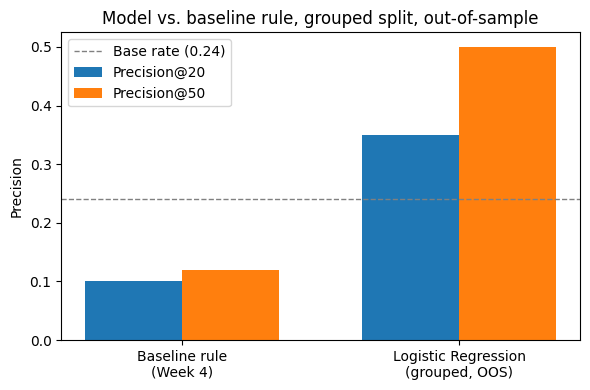

Saved work/figures/model_vs_baseline_precision.png
Saved work/figures/monitoring_baseline.json
work/outputs/action_playbook_queue.csv: exists=True, size=19035905 bytes
work/figures/model_vs_baseline_precision.png: exists=True, size=45166 bytes
work/figures/monitoring_baseline.json: exists=True, size=357 bytes


In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os
import json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# ---- Export 1: full ranked queue (CSV, stays out of git) ----
export_cols = [
    "content_hash_id", "client_hash_id", "model_score", "reason_code",
    "recommended_action", "validation_status", "position_bucket", "age_bucket",
    "impressions_prior30", "impressions_current30", "is_declining_label",
]
ranked_queue[export_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Saved {len(ranked_queue)} rows to work/outputs/action_playbook_queue.csv")

# ---- Export 2: model vs baseline comparison figure (committed) ----
fig, ax = plt.subplots(figsize=(6, 4))
methods = ["Baseline rule\n(Week 4)", "Logistic Regression\n(grouped, OOS)"]
p20 = [0.10, 0.35]
p50 = [0.12, 0.50]

x = np.arange(len(methods))
width = 0.35
ax.bar(x - width/2, p20, width, label="Precision@20")
ax.bar(x + width/2, p50, width, label="Precision@50")
ax.axhline(y=0.24, color="gray", linestyle="--", linewidth=1, label="Base rate (0.24)")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Precision")
ax.set_title("Model vs. baseline rule, grouped split, out-of-sample")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline_precision.png", dpi=150)
plt.show()
print("Saved work/figures/model_vs_baseline_precision.png")

# ---- Export 3: monitoring baseline (JSON, committed, the paper's receipts) ----
with open("work/figures/monitoring_baseline.json", "w") as f:
    json.dump(monitoring_baseline, f, indent=2)
print("Saved work/figures/monitoring_baseline.json")

# ---- Sanity check: confirm all three files exist ----
for path in ["work/outputs/action_playbook_queue.csv",
             "work/figures/model_vs_baseline_precision.png",
             "work/figures/monitoring_baseline.json"]:
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    print(f"{path}: exists={exists}, size={size} bytes")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.